# Model Training Notebook Template

> **Purpose:** Use this notebook to document the full machine learning model development process for your project.  
> It is designed as a **deliverable template** for the task and can be adapted for classification, regression, forecasting, recommendation, anomaly detection, or clustering problems.

---

## How to use this notebook
1. Duplicate this notebook for your project.
2. Rename the notebook model_training_notebook_<student_number>.ipynb
3. Replace all placeholders marked with `TODO`.
4. Keep the narrative concise but evidence-based.
5. Record each important experiment, metric, and decision.
6. Make sure the final notebook clearly shows:
   - the problem being solved
   - the data used
   - the baseline
   - the models tried
   - evaluation and validation
   - error analysis
   - iterations and improvements
   - the final recommendation and business value
7. Make sure the final notebook is saved in your individual GitHub repo.
8. Make sure the notebook meets the [notebook submission guidelines](https://adsai.buas.nl/General/NotebookSubmissionRules.html).

---

## Deliverable alignment
This notebook is structured to support the required deliverable:

- **Model training notebook**
- Evidence for:
  - **ILO 8.4 A:** why the model is an appropriate solution
  - **ILO 8.4 B:** metrics, validation performance, limitations, and common errors
  - **ILO 8.4 C:** key iterations and how they improved performance

## Individual Deliverable

Note this notebook should be completed individually. Each member of the group is responsible for training and analysing their own model. You are free to choose which model or models your team chooses to integrate into your application.
This submission should be unique if your submission is too similar to other members of your group or the class your case will be assessed for academic dishonesty and may be referred to the BOE.


## 0. Project metadata

Fill in this section before starting.

- **Project title:** `TODO`
- **Notebook owner / author:** `TODO`


## 1. Problem definition

### 1.1 Prediction or analysis task
Describe the specific problem your model will solve.

**Template prompts**
- What is the prediction or analysis task?
- What input data is available at prediction time?
- What output should the model produce?
- Who will use the model or its outputs?

**Write-up**
> TODO

### 1.2 Business or project value
Explain why solving this problem matters.

**Template prompts**
- What decision will this model support?
- What is improved if the model works well?
- What risks exist if it performs poorly?

**Write-up**
> TODO

### 1.3 Success criteria
Define what “good enough” means for this project.

**Template prompts**
- Which metric matters most and why?
- What threshold or comparative improvement would count as success?
- What constraints matter besides accuracy (e.g. interpretability, latency, fairness, recall, cost)?

**Write-up**
> TODO


## 2. Data selection and preparation

Document where the data came from, how it was prepared, and any key limitations. If you use multiple datasets you need to discuss all of them here.

### 2.1 Dataset summary
- **Data source(s):** `TODO`
- **Collection period:** `TODO`
- **Unit of analysis:** `TODO`  
  Example: one customer, one transaction, one image, one day, one text sample
- **Target variable:** `TODO`
- **Key features:** `TODO`
- **Important exclusions or filters:** `TODO`

### 2.2 Risks and limitations
- Missing values: `TODO`
- Sampling bias: `TODO`
- Label quality issues: `TODO`
- Leakage risks: `TODO`
- Ethical/privacy concerns: `TODO`


In [1]:
import pandas as pd
df = pd.read_csv('../../../data/processed/msft_merged.csv')

### 2.3 Initial data inspection

Summarise the dataset datasets after loading it.

- Number of rows: `TODO`
- Number of columns: `TODO`
- Target class balance / target distribution: `TODO`
- Data types overview: `TODO`
- Key issues noticed in the raw data: `TODO`


In [2]:
print(df.shape)
print(df.info())
df.head()

(2818, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2818 entries, 0 to 2817
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2818 non-null   str    
 1   Open        2818 non-null   float64
 2   High        2818 non-null   float64
 3   Low         2818 non-null   float64
 4   Close       2818 non-null   float64
 5   Volume      2818 non-null   float64
 6   gold_close  2818 non-null   float64
 7   oil_close   2818 non-null   float64
 8   vix         2818 non-null   float64
 9   spy_close   2818 non-null   float64
dtypes: float64(9), str(1)
memory usage: 220.3 KB
None


,Date,Open,High,Low,Close,Volume,gold_close,oil_close,vix,spy_close
0,2015-02-17,43.97,44.0000,43.19,43.580,33695149.0,1208.099976,53.529999,15.80,174.000732
1,2015-02-18,43.63,43.7000,43.39,43.530,27111657.0,1199.699951,52.139999,15.45,174.017288
2,2015-02-19,43.18,43.5263,43.05,43.500,27556420.0,1207.099976,51.160000,15.29,173.893082
3,2015-02-20,43.51,43.8800,43.29,43.855,29721133.0,1204.400024,50.340000,14.30,174.936493
4,2015-02-23,43.70,44.1900,43.65,44.150,32518754.0,1200.300049,49.450001,14.56,174.911667


In [3]:
# include rows with date only past January 1, 2019
df = df[df['Date'] >= '2019-01-01']
print(df.shape)

(1842, 10)


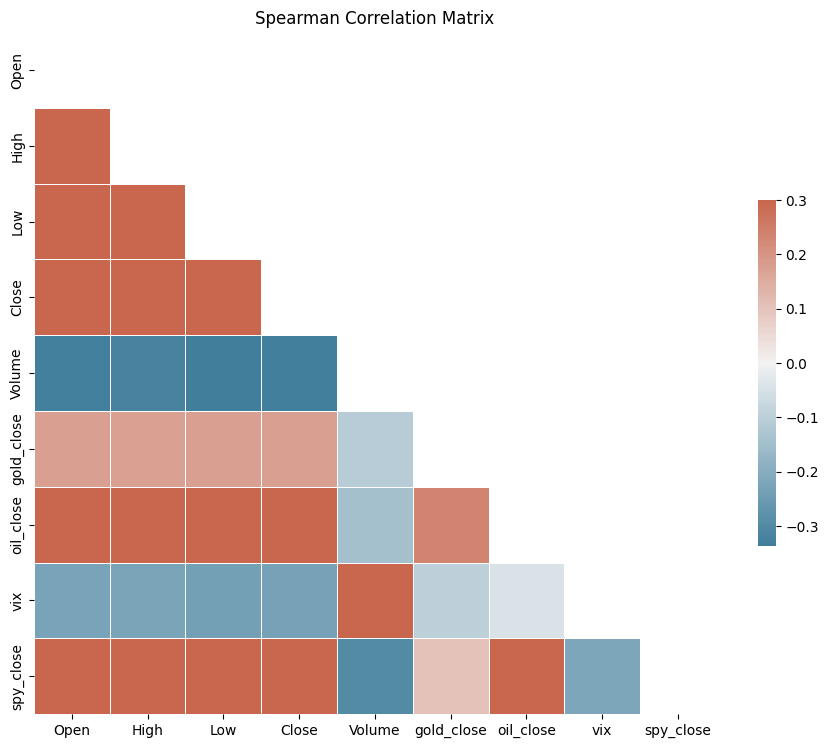

In [4]:
# create an appealing spearman correlation matrix and excluding 'date' column from dataframe 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Calculate the correlation matrix
corr = df.iloc[:, 1:].corr(method='spearman')
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Spearman Correlation Matrix')
plt.show()

### 2.4 Preprocessing decisions

Explain the preprocessing choices you made.

**Template prompts**
- How did you handle missing values?
- How did you encode categorical variables?
- Did you scale numeric features?
- Did you create new features?
- Did you remove features for leakage, irrelevance, or multicollinearity?
- Did you use a time-based split instead of a random split?
- Any other preprocessing steps?

**Write-up**
> TODO


In [5]:
# drop Volumne and vix columns. Create a new column "Direction" with 1 if the next day's closing price is higher than the current day's closing price, and 0 otherwise. The threshold value is 0.5% to account for minor fluctuations.
df = df.drop(columns=['Volume', 'vix'])
df['Direction'] = (df['Close'].shift(-1) > df['Close'] * 1.005).astype(int)
print(df.head())

           Date    Open      High       Low   Close   gold_close  oil_close  \
976  2019-01-02   99.55  101.7500   98.9400  101.12  1281.000000  46.540001   
977  2019-01-03  100.10  100.1850   97.2000   97.40  1291.800049  47.090000   
978  2019-01-04   99.72  102.5100   98.9300  101.93  1282.699951  47.959999   
979  2019-01-07  101.64  103.2681  100.9800  102.06  1286.800049  48.520000   
980  2019-01-08  103.04  103.9700  101.7134  102.80  1283.199951  49.779999   

      spy_close  Direction  
976  224.382553          0  
977  219.028107          1  
978  226.364639          0  
979  228.149460          1  
980  230.292999          1  


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['day_of_week']    = df['Date'].dt.dayofweek      # 0=Mon, 4=Fri
df['day_of_month']   = df['Date'].dt.day            # 1–31
df['month']          = df['Date'].dt.month          # 1–12
df['quarter']        = df['Date'].dt.quarter        # 1–4
df['year']           = df['Date'].dt.year
df['week_of_year']   = df['Date'].dt.isocalendar().week.astype(int)

In [7]:
import numpy as np

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 5)   # 5 trading days
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 5)

df['dom_sin']   = np.sin(2 * np.pi * df['day_of_month'] / 31)
df['dom_cos']   = np.cos(2 * np.pi * df['day_of_month'] / 31)

## 3. Validation strategy

State clearly how you will validate model performance.

### 3.1 Chosen validation approach
Select the method that best matches your problem:
- Train/test split
- Cross-validation
- Stratified split
- Time-based validation
- Backtesting / rolling window validation
- Group-based split

**Justification**
> TODO: explain why this validation method is appropriate for your problem and data.

### 3.2 Leakage prevention
Explain how you reduced leakage risk.

**Write-up**
> TODO


In [ ]:
# split data 80/10/10 for train/validation/test
from sklearn.model_selection import train_test_split

date_series = df['Date'].copy()  # keep aside for splitting
X = df.drop(columns=['Date', 'Direction'])
y = df['Direction']

X_train, X_temp, y_train, y_temp, date_train, date_temp = train_test_split(X, y, date_series, test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test, date_val, date_test = train_test_split(X_temp, y_temp, date_temp, test_size=0.5, shuffle=False)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (1473, 19), Val: (184, 19), Test: (185, 19)


## 4. Baseline model

A baseline gives you something simple to compare against.

### 4.1 Baseline approach
Describe the baseline and why it is a reasonable minimum benchmark.

Examples:
- Predict the most frequent class
- Predict the mean/median target
- Previous-period value for forecasting
- Simple rule-based heuristic
- Existing manual process

**Write-up**
> TODO


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report 

baseline_model = RandomForestClassifier(n_estimators=50, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.84      0.73       122
           1       0.21      0.08      0.12        62

    accuracy                           0.59       184
   macro avg       0.43      0.46      0.42       184
weighted avg       0.50      0.59      0.52       184



In [15]:
print("Baseline Model Performance:")
print(classification_report(y_val, y_pred))

Baseline Model Performance:
              precision    recall  f1-score   support

           0       0.64      0.84      0.73       122
           1       0.21      0.08      0.12        62

    accuracy                           0.59       184
   macro avg       0.43      0.46      0.42       184
weighted avg       0.50      0.59      0.52       184



### 4.2 Baseline results
Record the baseline performance here.

| Metric | Baseline result | Notes |
|---|---:|---|
| Primary metric | TODO | TODO |
| Secondary metric | TODO | TODO |
| Other metric | TODO | TODO |

**Interpretation**
> TODO: explain what the baseline tells you.


## 5. Candidate models

List the models you plan to try and why they are appropriate.

| Model | Why this model is suitable | Key strengths | Main risks / limitations |
|---|---|---|---|
| LSTM | Suitable, becuase of "memory cells" architecture | Memory | Computational Power |
| ARIMA | Suitable, because forecasts short term fluctuations | Perfect for next-day movement forecast | Requires linear data |
| Naive Bayesian Classifier | Suitable, because it is an efficient ML classification algorithm | Efficiency and simplicity | Sensitive to outliers |

**Selection rationale**
> TODO


## 6. Evaluation framework

Before training, define the metrics you will use and why.

### 6.1 Primary metric
Choose the main metric used to compare models.

**Examples**
- Classification: F1, recall, precision, ROC-AUC, PR-AUC, balanced accuracy
- Regression: RMSE, MAE, R², MAPE
- Forecasting: MAE, RMSE, sMAPE, MASE
- Ranking/recommendation: MAP@K, Recall@K, NDCG

**Justification**
> TODO

### 6.2 Secondary metrics
Add supporting metrics that capture other aspects of performance.

**Write-up**
> TODO


## 7. Train and evaluate models

Train each candidate model and compare results systematically.


In [ ]:
# implement naive bayes classifier
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(train_df.drop(columns=['Direction', 'Date']), train_df['Direction'])
nb_predictions = nb_model.predict(test_df.drop(columns=['Direction', 'Date']))
print("Naive Bayes Model Performance:")
print(classification_report(test_df['Direction'], nb_predictions))


In [ ]:
# plot the graph of naive bayesian classifier predictions vs actual values
import matplotlib.dates as mdates

plot_dates = pd.to_datetime(test_df['Date'])

plt.figure(figsize=(10, 6))
plt.plot(plot_dates, test_df['Direction'], label='Actual', marker='o')
plt.plot(plot_dates, nb_predictions, label='Naive Bayes Predictions', marker='x')
plt.xlabel('Year')
plt.ylabel('Direction')
plt.title('Naive Bayes Predictions vs Actual Values')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
ARIMA model


In [ ]:
# implement ARIMA model, show the results and the plot same as above
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(train_df['Direction'], order=(5, 1, 0))
arima_result = arima_model.fit()
arima_predictions = arima_result.predict(start=len(train_df), end=len(train_df)+len(test_df)-1, typ='levels')
print("ARIMA Model Performance:")
print(classification_report(test_df['Direction'], arima_predictions.round().astype(int)))

### 7.1 Model comparison summary

| Model | Primary metric | Secondary metrics | Better than baseline? | Notes |
|---|---:|---|---|---|
| Baseline | TODO | TODO | — | TODO |
| Model 1 | TODO | TODO | TODO | TODO |
| Model 2 | TODO | TODO | TODO | TODO |
| Model 3 | TODO | TODO | TODO | TODO |

**Interpretation**
> TODO: explain which model(s) look most promising and why.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# Scale the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Create sequences
def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 60 # Using 60 days of historical data to predict the next day

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, TIME_STEPS)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, TIME_STEPS)

print(f'Train sequences: {X_train_seq.shape}')
print(f'Validation sequences: {X_val_seq.shape}')
print(f'Test sequences: {X_test_seq.shape}')

---
LSTM model

In [ ]:
# initialization and training

## 8. Iteration and improvement

This section should show how you refined your approach over time.

Typical improvements:
- alternative algorithms
- hyperparameter tuning
- feature engineering
- better preprocessing
- class balancing
- threshold tuning
- regularisation changes
- better handling of missing data
- different validation setup

Record each meaningful iteration.


In [ ]:
 # TODO: Iteratively improve your models



### 8.1 Iteration log

Duplicate rows as needed.

| Iteration | Change made | Reason for change | Result | Decision |
|---|---|---|---|---|
| 1 | TODO | TODO | TODO | TODO |
| 2 | TODO | TODO | TODO | TODO |
| 3 | TODO | TODO | TODO | TODO |

### 8.2 What improved performance?
> TODO

### 8.3 What did not help?
> TODO


## 9. Error analysis

Go beyond summary metrics and inspect where the model fails.

### 9.1 Questions to answer
- Which examples are commonly misclassified or badly predicted?
- Are errors concentrated in specific classes, ranges, segments, or time periods?
- Are there data quality issues causing errors?
- Are some features misleading or unstable?
- Are there fairness or subgroup performance concerns?

### 9.2 Error analysis write-up
> TODO


In [ ]:
# TODO: inspect predictions and errors



In [ ]:
# TODO: create an error analysis table



## 10. Validation results

Summarise how the chosen model performed under the selected validation method.

### 10.1 Validation approach used
> TODO

### 10.2 Validation results
| Metric | Validation result | Interpretation |
|---|---:|---|
| Primary metric | TODO | TODO |
| Secondary metric | TODO | TODO |
| Secondary metric | TODO | TODO |

### 10.3 Robustness and limitations
Discuss uncertainty and known weaknesses.

**Template prompts**
- How stable were results across folds or time periods?
- Is the model likely to generalise?
- What important limitations remain?
- What common errors were observed?
- Under what conditions might the model fail?

**Write-up**
> TODO


## 11. Final model selection

Choose your best and most appropriate model from the models you have trained above and complete the following sections.

### 11.1 Selected model
- **Model name:** `TODO`
- **Version / configuration:** `TODO`
- **Why this model was selected:** `TODO`

### 11.2 Justification for appropriateness (ILO 8.4 A)
Use this section to justify why your chosen model is an appropriate solution to the problem.

**Template prompts**
- Why does this model fit the task and data?
- Why is it preferable to the alternatives you tested?
- What trade-offs did you accept?

**Write-up**
> TODO

### 11.3 Metrics, validation, and limitations (ILO 8.4 B)
Summarise the metrics used, validation performance, limitations, and common errors.

**Write-up**
> TODO

### 11.4 Key iterations and improvements (ILO 8.4 C)
Summarise the main iterations and how they improved performance.

**Write-up**
> TODO
